In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
def f(x):
      return (3*x**2) - (4*x) + 5

In [ ]:
f(3)

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys

In [ ]:
plt.plot(xs, ys)

In [ ]:
h = 0.0000001
x = 2/3
(f(x + h) - f(x))/h

In [ ]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h 
d2 = a*b + c

print(f"d1 is {d1}. d2 is {d2}. slope is {(d2 - d1)/h}")

### Neural Networks
* Honestly can't wait 


In [28]:
class Value:
    def __init__(self, data, _children=(), _op="", label = ""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children) #for efficiency
        self._op = _op 
        self.label = label
    def __repr__(self):
        return f"Value(data = {self.data})"
            
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+", )
        return out 
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out 
    def __exp__(self, other):
        out = Value(self.data ** other.data, (self, other), "**")
        return out
     

a = Value(2.0, label = "a")
b = Value(-3.0, label = "b")
c = Value(10.0, label = "c")
d = a * b + c
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label = "f")
l = d * f; l.label = "l"



"""
e = d ** 2 
f = e ** 2(a+b) 
g = 100/f
print(f"{g.data:.4f}")
"""
l

Value(data = -8.0)

In [ ]:
d._prev 

In [38]:
from graphviz import Digraph  

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot =  Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges =  trace(root)
    for n in nodes:
        uid = str(id(n)) 
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad%.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node 
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot
         


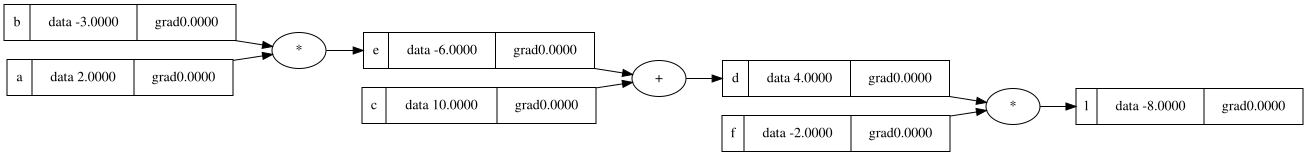

In [39]:
draw_dot(l)

In [ ]:
trace(d)